### Data Selection for Finetuning Ag slab w/ [C, H, O] adsorbates

Download OUTCAR for each pre-screened folder listed in cache/selected_foldernames.txt

In [7]:
import os
import time
import re
import glob
from pathlib import Path
from dotenv import load_dotenv
import dropbox
from dropbox.files import SharedLink

load_dotenv(override=True)
TOKEN = os.getenv("DROPBOX_TOKEN")

In [8]:
# read in raw folder names list from cache
with open("cache/selected_foldernames.txt", "r", encoding="utf-8") as f:
    foldernames = [line.strip() for line in f]

print(f"Total items: {len(foldernames)}")

Total items: 143


In [9]:
dbx = dropbox.Dropbox(TOKEN, timeout=900)
ROOT_PATH = SharedLink(url="https://www.dropbox.com/scl/fo/qpg1zuo3g7vb3il1wmqy3/AA4wERzz28lJhYTCAcSEvqk?dl=0")

In [4]:
# get all numeric suffixes N among files named '{prefix}-N' in names
def all_suffixes(names, prefix):
      # params:  names  - iterable[str], filenames from a folder listing
      #          prefix - str, base filename to match (e.g. "OUTCAR")
      # return:  list[int] - all N found (empty list if none)
      return [int(m.group(1)) for n in names
            if (m := re.fullmatch(rf"{prefix}-(\d+)", n))]


# get highest-enumerated file in folder
def max_suffix(names, prefix):
      # highest N for '{prefix}-N' in names, else None
      # names: iterable[str], filenames from a folder listing
      # prefix: base filename (eg. "INCAR")
      ns = (int(m.group(1)) for n in names
            if (m := re.fullmatch(rf"{prefix}-(\d+)", n)))
      return max(ns, default=None)

In [5]:
# download file from dropbox

# # overwrites existing files
# def download_file(folder, fname, outdir):
#     _, res = dbx.sharing_get_shared_link_file(url=ROOT_PATH.url, path=f"/{folder}/{fname}")
#     with open(f"{outdir}/{folder}_{fname}", "wb") as f:
#         f.write(res.content)

# skips writing already-existing files:
def download_file(folder, fname, outdir):
    out_path = f"{outdir}/{folder}_{fname}"
    if os.path.exists(out_path):
        return
    _, res = dbx.sharing_get_shared_link_file(url=ROOT_PATH.url, path=f"/{folder}/{fname}")
    with open(out_path, "wb") as f:
        f.write(res.content)

In [10]:
# call dropbox API here to download OUTCARs and INCARs without repeat calls

no_outcars, no_incars, failed_folders = [], [], {}

for folder in foldernames:
    folder_path = f"/{folder}"
    try:
        res = dbx.files_list_folder(path=folder_path, shared_link=ROOT_PATH)
        names = {e.name for e in res.entries}
    except dropbox.exceptions.ApiError as e:
        failed_folders[folder] = str(e)
        print(f"ERROR: folder listing failed -> {folder}: {e}")
        continue
    
    # download all OUTCARs in DFT run folder
    if "OUTCAR" not in names:
        no_outcars.append(folder)
        print(f"MISSING: no OUTCAR in -> {folder}")
    else:
        try:
            download_file(folder, "OUTCAR", "outcars")
            for n in all_suffixes(names, "OUTCAR"):
                download_file(folder, f"OUTCAR-{n}", "outcars")
        except dropbox.exceptions.ApiError as e:
            failed_folders[folder] = str(e)
            print(f"ERROR: OUTCAR download failed -> {folder}: {e}")
    
    # download highest-enumerated INCAR in each folder
    if "INCAR" not in names:
        no_incars.append(folder)
        print(f"MISSING: no INCAR in -> {folder}")
    else:
        try:
            max_i = max_suffix(names, "INCAR")
            last_incar = f"INCAR-{max_i}" if max_i is not None else "INCAR"
            download_file(folder, last_incar, "incars")
        except dropbox.exceptions.ApiError as e:
            no_incars.append(folder)
            print(f"ERROR: INCAR download failed -> {folder}: {e}")

    time.sleep(0.2)

print(f"No OUTCAR: {len(no_outcars)} | No/failed INCAR: {len(no_incars)} | Failed folder listings: {len(failed_folders)}")

No OUTCAR: 0 | No/failed INCAR: 0 | Failed folder listings: 0


Get energy trajectories of each run to plot and check for convergence

In [ ]:
# gets "Free energy (TOTEN)" at each ionic step in an OUTCAR file.

def get_energies(outcar_path):
    energies = []
    with open(outcar_path, "r", errors="ignore") as f:
        for line in f:
            if "free  energy   TOTEN" in line:
                energies.append(float(line.split()[-2]))
    return energies

def get_all_energies_with_bounds(folder, outcar_dir="outcars", suffix_map=None):
    max_n = suffix_map.get(folder) if suffix_map else None
    base_path = f"{outcar_dir}/{folder}_OUTCAR"
    energies = get_energies(base_path) if os.path.exists(base_path) else []
    bounds = [len(energies)]
    if max_n is not None:
        for i in range(1, max_n + 1):
            energies += get_energies(f"{outcar_dir}/{folder}_OUTCAR-{i}")
            bounds.append(len(energies))
    return energies, bounds[:-1]


Remove uncoverged runs where the # of ionic steps taken in the last OUTCAR = NSW (max step limit)

In [12]:
# get max OUTCAR suffix per folder (from already-downloaded files)
def build_suffix_map(foldernames, outdir="outcars"):
    # returns:  dict[str, int|None] - folder -> max OUTCAR-N suffix (None if base only)

    suffix_map = {}
    for folder in foldernames:
        names = {os.path.basename(p)[len(folder) + 1:]
                for p in glob.glob(f"{outdir}/{folder}_OUTCAR*")}
        suffix_map[folder] = max_suffix(names, "OUTCAR")
    return suffix_map

suffix_map = build_suffix_map(foldernames)

In [13]:
def get_nsw(folder, max_n, incar_dir="incars"):
    incar_name = "INCAR" if max_n is None else f"INCAR-{max_n}"
    with open(f"{incar_dir}/{folder}_{incar_name}", "r", errors="ignore") as f:
        for line in f:
            if line.strip().upper().startswith("NSW"):
                return int(line.split("=")[1].split()[0])
    return None

In [14]:
# compare ionic steps taken in last OUTCAR segment to NSW for a folder

def compare_to_nsw(folder, outcar_dir="outcars", incar_dir="incars", suffix_map=None):
    max_n = suffix_map.get(folder) if suffix_map else None
    outcar_name = "OUTCAR" if max_n is None else f"OUTCAR-{max_n}"
    actual = len(get_energies(f"{outcar_dir}/{folder}_{outcar_name}"))
    nsw = get_nsw(folder, max_n, incar_dir)
    return {"actual": actual, "nsw": nsw, "hit_limit": nsw is not None and actual >= nsw}

In [15]:
compare_to_nsw(foldernames[1], suffix_map=suffix_map)

{'actual': 163, 'nsw': 400, 'hit_limit': False}

In [16]:
# delete all INCAR/OUTCAR files for a folder, remove it from foldernames list,
# write the updated foldernames to cache/screened_foldernames.txt

def delete_run(folder, foldernames, outdir_out="outcars", outdir_in="incars", cache_dir="cache"):
    for fpath in glob.glob(f"{outdir_out}/{folder}_OUTCAR*") + glob.glob(f"{outdir_in}/{folder}_INCAR*"):
        os.remove(fpath)
    if folder in foldernames:
        foldernames.remove(folder)
        print(f"Deleted run -> {folder}")
    os.makedirs(cache_dir, exist_ok=True)
    with open(f"{cache_dir}/screened_foldernames.txt", "w") as f:
        f.write("\n".join(foldernames))

In [17]:
# screen runs: if the last OUTCAR segment hit NSW, delete run
# if too few ionic steps, delete run

MIN_STEPS = 5

for folder in list(foldernames):
    result = compare_to_nsw(folder, suffix_map=suffix_map)
    if result["hit_limit"]:
        print(f"SCREENED OUT: {folder} (steps={result['actual']}, NSW={result['nsw']})")
        delete_run(folder, foldernames)
    elif result["actual"] < MIN_STEPS:
        print(f"SCREENED OUT: {folder} (only {result['actual']} ionic steps)")
        delete_run(folder, foldernames)

SCREENED OUT: 2OAg (steps=40, NSW=40)
Deleted run -> 2OAg
SCREENED OUT: O4Ag_Tetra_1 (only 3 ionic steps)
Deleted run -> O4Ag_Tetra_1
SCREENED OUT: OAg_100_4x4_vac_1 (only 3 ionic steps)
Deleted run -> OAg_100_4x4_vac_1
SCREENED OUT: OAg_100_4x4_vac_2 (only 2 ionic steps)
Deleted run -> OAg_100_4x4_vac_2
SCREENED OUT: OAg_100_4x4_vac_3 (only 3 ionic steps)
Deleted run -> OAg_100_4x4_vac_3
SCREENED OUT: OAg_100_4x4_vac_4 (only 1 ionic steps)
Deleted run -> OAg_100_4x4_vac_4
SCREENED OUT: OAg_100_4x4_vac_5 (only 3 ionic steps)
Deleted run -> OAg_100_4x4_vac_5
SCREENED OUT: Ag100_O+Ethylene_1 (only 3 ionic steps)
Deleted run -> Ag100_O+Ethylene_1


In [18]:
print(len(foldernames))

135


Check energy trajectory of runs.

In [19]:
import math
import matplotlib.pyplot as plt

def downsample(vals, max_points=30):
    if len(vals) <= max_points:
        return list(range(1, len(vals)+1)), vals
    idx = [round(i * (len(vals)-1) / (max_points-1)) for i in range(max_points)]
    idx = sorted(set(idx))
    return [i+1 for i in idx], [vals[i] for i in idx]

def plot_energy_trajectories(folders, outcar_dir="outcars", suffix_map=None):
    n = len(folders)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]
    for ax, folder in zip(axes, folders):
        try:
            energies, bounds = get_all_energies_with_bounds(folder, outcar_dir, suffix_map)
            steps, e = downsample(energies)
            ax.plot(steps, e, marker="o", markersize=3)
            for b in bounds:
                ax.axvline(x=b, color="red", linestyle="--", linewidth=0.7)
            ax.text(0.98, 0.95, f"n={len(energies)}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8)
        except Exception as ex:
            ax.text(0.5, 0.5, f"failed: {ex}", ha="center", va="center")
        ax.set_title(folder, fontsize=9)
        ax.set_xlabel("step")
        ax.set_ylabel("E (eV)")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [102]:
# print folder names with absolute indexes, skip empty
for i, folder in enumerate(foldernames):
    if not folder:
        continue
    if 110 > i > 90:
        print(i, folder)

91 CO3_Osub_Ag100_alt
92 CO3_Osub_Ag100_alt2
93 CO3_Osub_Ag100_2x2
94 Ag100_O5Phase_CO3Substitution
95 Ag100_O5Phase_O2
96 Ag100_O5Phase_Ovac
97 Ag100_O5Phase_CO3Substitution_withsub
98 Ag100_O5Phase_O2_withsub
99 Ag100_O5Phase_Ovac_withsub


In [100]:
# delete the first OUTCAR for flagged folders w/multiple OUTCARs

def delete_first_outcars(idxs, outcar_dir="outcars"):
    for i in idxs:
        folder = foldernames[i]
        if not folder:
            continue
        path = f"{outcar_dir}/{folder}_OUTCAR"
        print(path)
        if os.path.exists(path):
            os.remove(path)
            print(f"Deleted first OUTCAR -> {folder}")

idxs = [91, 92, 94, 95, 97, 96, 99]  # remove 1st OUTCAR
delete_first_outcars(idxs)


outcars/CO3_Osub_Ag100_alt_OUTCAR
outcars/CO3_Osub_Ag100_alt2_OUTCAR
outcars/Ag100_O5Phase_CO3Substitution_OUTCAR
outcars/Ag100_O5Phase_O2_OUTCAR
outcars/Ag100_O5Phase_CO3Substitution_withsub_OUTCAR
Deleted first OUTCAR -> Ag100_O5Phase_CO3Substitution_withsub
outcars/Ag100_O5Phase_Ovac_OUTCAR
outcars/Ag100_O5Phase_Ovac_withsub_OUTCAR


In [103]:
# delete entries
del_idxs = [98, 99]  # remove run

targets = [foldernames[d] for d in del_idxs]
for name in targets:
    delete_run(name, foldernames)
print(f"Total items: {len(foldernames)}")

Deleted run -> Ag100_O5Phase_O2_withsub
Deleted run -> Ag100_O5Phase_Ovac_withsub
Total items: 98


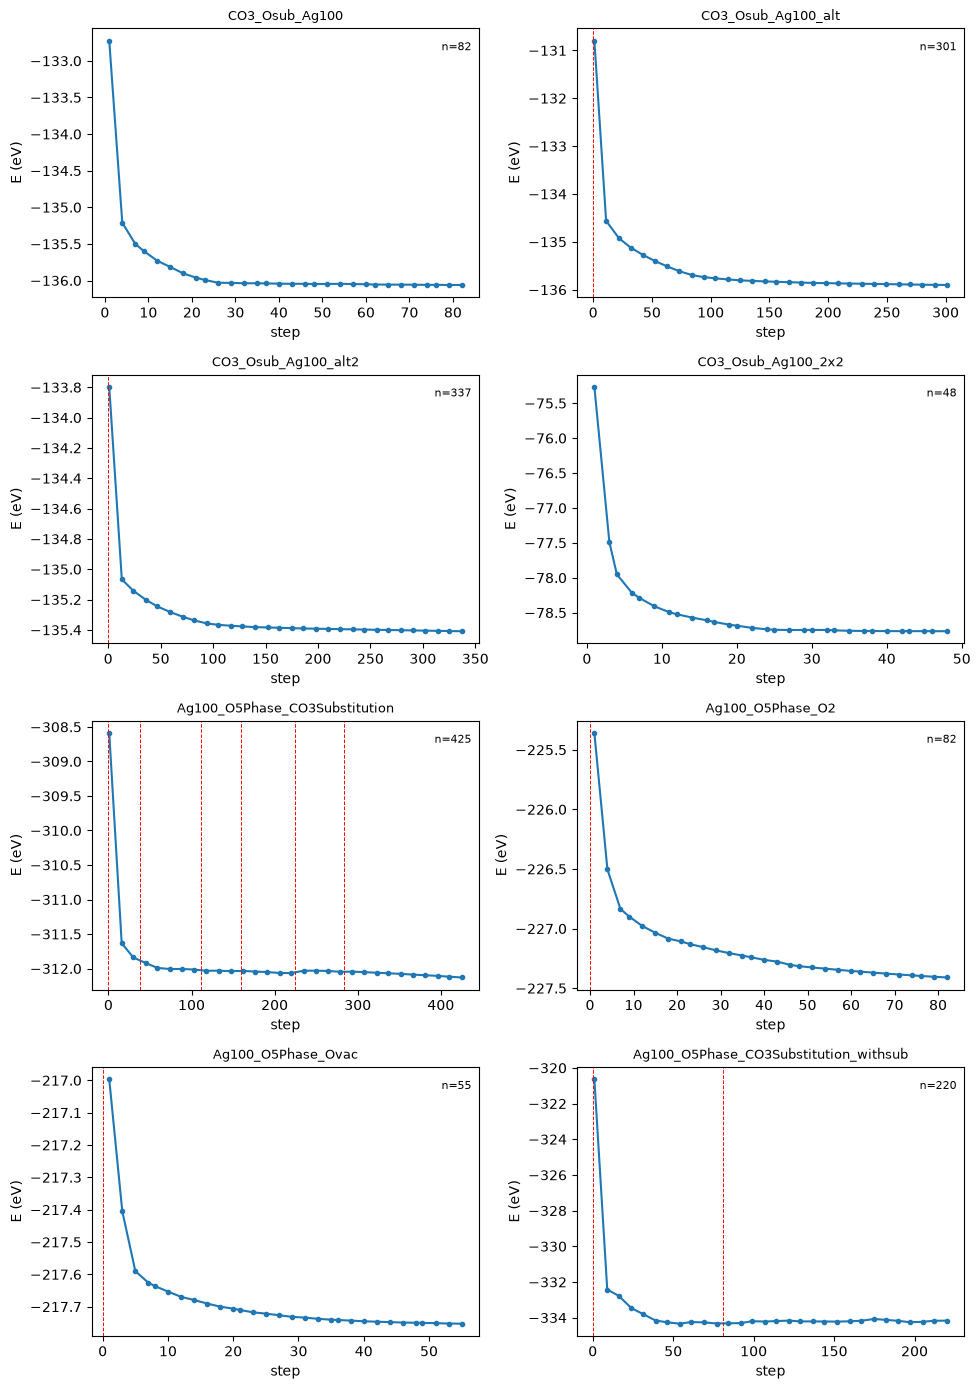

In [104]:
folderlist = foldernames[90:100]
suffix_map = build_suffix_map(foldernames)

plot_energy_trajectories(folderlist, suffix_map=suffix_map)

In [105]:
with open(f"cache/screened_foldernames.txt", "w") as f:
        f.write("\n".join(foldernames))